In [7]:
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [8]:
import cv2

cap = cv2.VideoCapture(
    "data/EchoNet-Dynamic/Videos/sample.mp4"
)

if not cap.isOpened():
    raise RuntimeError(
        "Could not open video"
    )


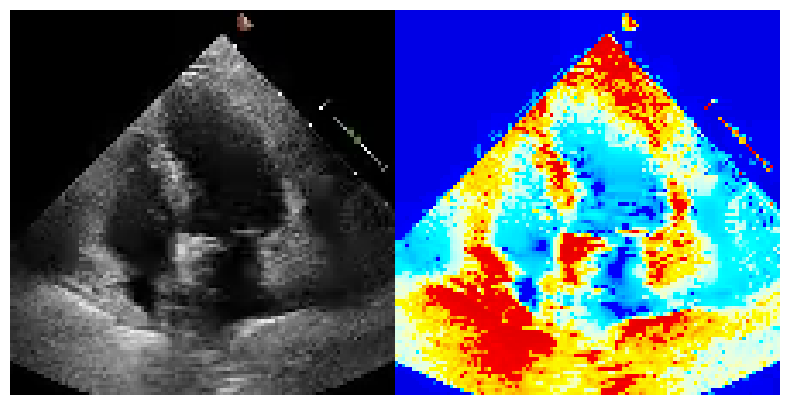

In [9]:
from IPython.display import clear_output
import time

while True:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2GRAY
    )

    equalized = cv2.equalizeHist(
        gray
    )

    heatmap = cv2.applyColorMap(
        equalized,
        cv2.COLORMAP_JET
    )

    b, g, r = cv2.split(
        heatmap
    )

    b = cv2.convertScaleAbs(
        b,
        alpha=1.0
    )

    g = cv2.convertScaleAbs(
        g,
        alpha=1.05
    )

    r = cv2.convertScaleAbs(
        r,
        alpha=0.95
    )

    balanced = cv2.merge(
        [b, g, r]
    )

    log_frame = np.log1p(
        balanced.astype(np.float32)
    )

    log_frame = cv2.normalize(
        log_frame,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    gamma = 0.8

    enhanced = np.power(
        log_frame.astype(np.float32)
        / 255.0,
        gamma
    )

    enhanced = (
        enhanced * 255
    ).astype(np.uint8)

    combined = cv2.hconcat(
        [frame, enhanced]
    )

    rgb = cv2.cvtColor(combined, cv2.COLOR_BGR2RGB)
    clear_output(wait=True)
    plt.figure(figsize=(10, 5))
    plt.imshow(rgb)
    plt.axis('off')
    plt.show()
    time.sleep(1 / 50)  # match the video's FPS


cap.release()

cv2.destroyAllWindows()
